# ANA500 — Lesson 7: Inferential Statistics
## Independent and paired t-tests, effect sizes, and boxplots

This notebook analyzes the supplied **Earnings and Screen Time** dataset. It addresses all four assignment tasks:

1. Test the difference in mean earnings between people with and without kids.
2. Test the mean sleep difference between screen and no-screen conditions for the same people.
3. Create both required boxplots.
4. Interpret statistical significance, effect sizes, and visualizations.

**Conventions:** two-sided tests; significance level $\alpha = 0.05$. The effect size follows the assignment formula $r = \sqrt{\frac{t^2}{t^2 + df}}$.

In [1]:
import numpy as np
from scipy import stats
from scipy.stats import norm
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns
import pingouin as pg
from pathlib import Path

from statsmodels.graphics.gofplots import qqplot

In [2]:
# Reusable code blocks
# box plots by categorical variable
def plot_boxplot(
    data: pd.DataFrame,
    x_categorical:str,
    y_numerical:str,
    title:str|None = None,
    ax:plt.Axes|None = None,
    display_stats:bool = False,
    order: list | None = None) -> plt.Axes:
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 6))
        
    if order is None:
        order = data[x_categorical].dropna().unique().tolist()
    
    sns.boxplot(
        data=data,
        x=x_categorical,
        y=y_numerical,
        order=order,
        ax=ax
    )
    
    if display_stats:
    
        # Calculate summary statistics for each group
        summary = data.groupby(x_categorical)[y_numerical].agg(
            count="count",
            mean="mean",
            median="median",
            std="std"
        ).reindex(order)

        # Display statistics above each box
        for i, (group, row) in enumerate(summary.iterrows()):
            stats_text = (
                f"n = {row['count']:.0f}\n"
                f"Mean = {row['mean']:.2f}\n"
                f"Median = {row['median']:.2f}\n"
                f"SD = {row['std']:.2f}"
            )

            ax.text(
                i-0.2, 0.98, stats_text,
                transform=ax.get_xaxis_transform(),
                ha="center",
                va="top",
                fontsize=9,
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
        )

    
    ax.set(
        title=title or f"{y_numerical.replace('_', ' ')} by {x_categorical.replace('_', ' ')}",
        xlabel=x_categorical.replace("_", " ").title(),
        ylabel=y_numerical.replace("_", " ").title()
    )
    
    ax.grid(visible=True, linestyle="--", alpha=0.7)
        
    return ax


## 1. Load and inspect the data

In [3]:
#1. load the festival dataset
project_root = Path.cwd().parents[0]
fname = project_root / "datasets" / "earnings and screen time.xlsx"

# verify the path
# print(fname)

df = pd.read_excel(fname)

print("Rows and columns:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nMissing values:")
print(df.isna().sum())
print("\nParental-status coding:")
print(df["kids"].value_counts(dropna=False).sort_index())
display(df.head())
display(df[["earnings", "sleep_screen", "sleep_noscreen"]].describe())

Rows and columns: (50, 5)

Column names: ['id', 'earnings', 'kids', 'sleep_screen', 'sleep_noscreen']

Missing values:
id                0
earnings          0
kids              0
sleep_screen      0
sleep_noscreen    0
dtype: int64

Parental-status coding:
kids
0    20
1    30
Name: count, dtype: int64


,id,earnings,kids,sleep_screen,sleep_noscreen
0,1,55,0,421,450
1,2,49,0,258,300
2,3,72,1,458,501
3,4,62,1,352,333
4,5,70,0,492,490


,earnings,sleep_screen,sleep_noscreen
count,50.000000,50.000000,50.000000
mean,59.520000,420.900000,432.400000
std,13.641533,88.261959,81.176301
min,32.000000,258.000000,296.000000
25%,49.250000,355.500000,377.000000
50%,60.000000,419.500000,433.000000
75%,69.000000,481.250000,501.750000
max,98.000000,666.000000,600.000000


### Data interpretation

There are 50 people. `kids` is coded 0 for no kids and 1 for kids. Earnings are measured in thousands of dollars. The two sleep columns are repeated measurements from the same people, so they must be analyzed as paired observations.

## 2. Independent t-test: earnings

**Research question:** Do mean earnings differ between people with and without kids?

$$
H_0: \mu_{\text{without}} - \mu_{\text{with}} = 0
$$

$$
H_1: \mu_{\text{without}} - \mu_{\text{with}} \ne 0
$$

Welch's independent t-test is used because the groups contain different people and it does not assume equal population variances.

In [4]:
earnings_no_kids = df.loc[df["kids"] == 0, "earnings"].dropna()
earnings_kids = df.loc[df["kids"] == 1, "earnings"].dropna()

earnings_summary = pd.DataFrame({
    "Group": ["without kids", "with kids"],
    "n": [len(earnings_no_kids), len(earnings_kids)],
    "Mean (k$)": [earnings_no_kids.mean(), earnings_kids.mean()],
    "SD (k$)": [earnings_no_kids.std(ddof=1), earnings_kids.std(ddof=1)]
})
display(earnings_summary.round(3))

earnings_test = stats.ttest_ind(
    earnings_no_kids, earnings_kids, equal_var=False
)

n1, n0 = len(earnings_no_kids), len(earnings_kids)
s1_sq, s0_sq = earnings_no_kids.var(ddof=1), earnings_kids.var(ddof=1)
se_earn = np.sqrt(s1_sq/n1 + s0_sq/n0)
df_earn = (s1_sq/n1 + s0_sq/n0)**2 / (
    (s1_sq/n1)**2/(n1-1) + (s0_sq/n0)**2/(n0-1)
)
mean_diff_earn = earnings_no_kids.mean() - earnings_kids.mean()
t_earn = earnings_test.statistic
p_earn = earnings_test.pvalue
r_earn = np.sqrt(t_earn**2 / (t_earn**2 + df_earn))

tcrit_earn = stats.t.ppf(0.975, df_earn)
ci_earn = (
    mean_diff_earn - tcrit_earn * se_earn,
    mean_diff_earn + tcrit_earn * se_earn
)

print(f"Mean difference (without − with): {mean_diff_earn:.3f} thousand dollars")
print(f"Standard error: {se_earn:.3f}")
print(f"t = {t_earn:.3f}")
print(f"df = {df_earn:.3f}")
print(f"Two-sided p-value = {p_earn:.6f}")
print(f"95% CI for mean difference = [{ci_earn[0]:.3f}, {ci_earn[1]:.3f}] thousand dollars")
print(f"Effect size r = {r_earn:.3f}")
print("Decision:", "Reject H0" if p_earn < 0.05 else "Fail to reject H0")

,Group,n,Mean (k$),SD (k$)
0,without kids,20,51.6,11.829
1,with kids,30,64.8,12.274


Mean difference (without − with): -13.200 thousand dollars
Standard error: 3.467
t = -3.808
df = 41.914
Two-sided p-value = 0.000451
95% CI for mean difference = [-20.197, -6.203] thousand dollars
Effect size r = 0.507
Decision: Reject H0


### Manual solution: independent t-test

**1. Difference between sample means**

$$
\bar{x}_1 - \bar{x}_0 = 51.6 - 64.8 = -13.2
$$

The sample mean difference is \(-13.2\) k dollars.

**2. Welch standard error**

$$
SE = \sqrt{\frac{s_1^2}{n_1} + \frac{s_0^2}{n_0}}
$$

$$
SE = \sqrt{\frac{11.829^2}{20} + \frac{12.274^2}{30}}
\approx 3.467
$$

**3. t-statistic**

$$
t = \frac{(\bar{x}_1 - \bar{x}_0) - 0}{SE}
$$

$$
t = \frac{-13.2}{3.467} \approx -3.808
$$

Welch's degrees of freedom are approximately \(41.914\).

**4. Effect size required by the assignment**

$$
r = \sqrt{\frac{t^2}{t^2 + df}}
$$

$$
r = \sqrt{\frac{(-3.808)^2}{(-3.808)^2 + 41.914}}
\approx 0.507
$$

### Reflection: earnings

The difference is statistically significant because \(p < 0.05\); therefore, reject the null hypothesis. The sample without kids has mean earnings $13.2k lower. The 95% confidence interval for the mean difference excludes zero. The effect size \(r \approx 0.507\) is large by common correlation-style guidelines. This association does not show that having kids causes higher earnings.

## 3. Paired t-test: sleep

**Research question:** Does average sleep duration differ between screen and no-screen conditions for the same people?

Define each person's difference as screen minus no screen:

$$
d_i = X_{\text{screen},i} - X_{\text{no-screen},i}
$$

The null and alternative hypotheses are:

$$
H_0: \mu_d = 0
$$

$$
H_1: \mu_d \ne 0
$$

The paired t-test analyzes the individual differences, not two independent groups.

In [5]:
sleep_screen = df["sleep_screen"].dropna()
sleep_noscreen = df["sleep_noscreen"].dropna()

sleep_summary = pd.DataFrame({
    "Condition": ["Screen", "No screen"],
    "n": [sleep_screen.count(), sleep_noscreen.count()],
    "Mean (minutes)": [sleep_screen.mean(), sleep_noscreen.mean()],
    "SD (minutes)": [sleep_screen.std(ddof=1), sleep_noscreen.std(ddof=1)]
})
display(sleep_summary.round(3))

# Keep paired rows together when calculating differences
paired_data = df[["sleep_screen", "sleep_noscreen"]].dropna()
differences = paired_data["sleep_screen"] - paired_data["sleep_noscreen"]
n_pairs = len(differences)

sleep_test = stats.ttest_rel(
    paired_data["sleep_screen"], paired_data["sleep_noscreen"]
)
mean_d = differences.mean()
sd_d = differences.std(ddof=1)
se_d = sd_d / np.sqrt(n_pairs)
df_sleep = n_pairs - 1
t_sleep = sleep_test.statistic
p_sleep = sleep_test.pvalue
r_sleep = np.sqrt(t_sleep**2 / (t_sleep**2 + df_sleep))

tcrit_sleep = stats.t.ppf(0.975, df_sleep)
ci_sleep = (
    mean_d - tcrit_sleep * se_d,
    mean_d + tcrit_sleep * se_d
)

print(f"Sum of paired differences: {differences.sum():.1f}")
print(f"Mean difference (screen − no screen): {mean_d:.3f} minutes")
print(f"SD of differences: {sd_d:.3f}")
print(f"Standard error: {se_d:.3f}")
print(f"t = {t_sleep:.3f}")
print(f"df = {df_sleep}")
print(f"Two-sided p-value = {p_sleep:.6f}")
print(f"95% CI for mean paired difference = [{ci_sleep[0]:.3f}, {ci_sleep[1]:.3f}] minutes")
print(f"Effect size r = {r_sleep:.3f}")
print("Decision:", "Reject H0" if p_sleep < 0.05 else "Fail to reject H0")

,Condition,n,Mean (minutes),SD (minutes)
0,Screen,50,420.9,88.262
1,No screen,50,432.4,81.176


Sum of paired differences: -575.0
Mean difference (screen − no screen): -11.500 minutes
SD of differences: 23.992
Standard error: 3.393
t = -3.389
df = 49
Two-sided p-value = 0.001391
95% CI for mean paired difference = [-18.318, -4.682] minutes
Effect size r = 0.436
Decision: Reject H0


In [6]:
# stats for manual solution
diff = (df["sleep_screen"] - df["sleep_noscreen"])
print(f"sum differences: {diff.sum()}")

print(f"std of differences: {diff.std()}")

sum differences: -575
std of differences: 23.99170775114449


### Manual solution: paired t-test

**1. Calculate individual differences**

$$
d_i = X_{\text{screen},i} - X_{\text{no-screen},i}
$$

**2. Mean difference**

$$
\bar{d} = \frac{\sum d_i}{n} = \frac{-575}{50} = -11.5
$$

**3. Standard deviation and standard error of the differences**

$$
s_d = \sqrt{\frac{\sum(d_i-\bar{d})^2}{n-1}}
$$

$$
s_d = \sqrt{\frac{28204.5}{49}} \approx 23.992
$$

$$
SE_{\bar{d}} = \frac{s_d}{\sqrt{n}}
$$

$$
SE_{\bar{d}} = \frac{23.992}{\sqrt{50}} \approx 3.393
$$

**4. t-statistic and degrees of freedom**

$$
t = \frac{\bar{d}-0}{s_d/\sqrt{n}}
$$

$$
t = \frac{-11.5}{3.393} \approx -3.389
$$

$$
df = n-1 = 49
$$

**5. Assignment effect size**

$$
r = \sqrt{\frac{t^2}{t^2+df}}
$$

$$
r = \sqrt{\frac{(-3.389)^2}{(-3.389)^2+49}} \approx 0.436
$$

### Reflection: sleep

The sleep difference is statistically significant because \(p < 0.05\); reject the null hypothesis. The mean paired difference is −11.5 minutes, meaning the sample slept less in the screen condition. The 95% confidence interval lies below zero. The effect size \(r \approx 0.436\) falls between common medium (0.30) and large (0.50) guidelines. The result alone does not establish causation.

## 4. Visualization

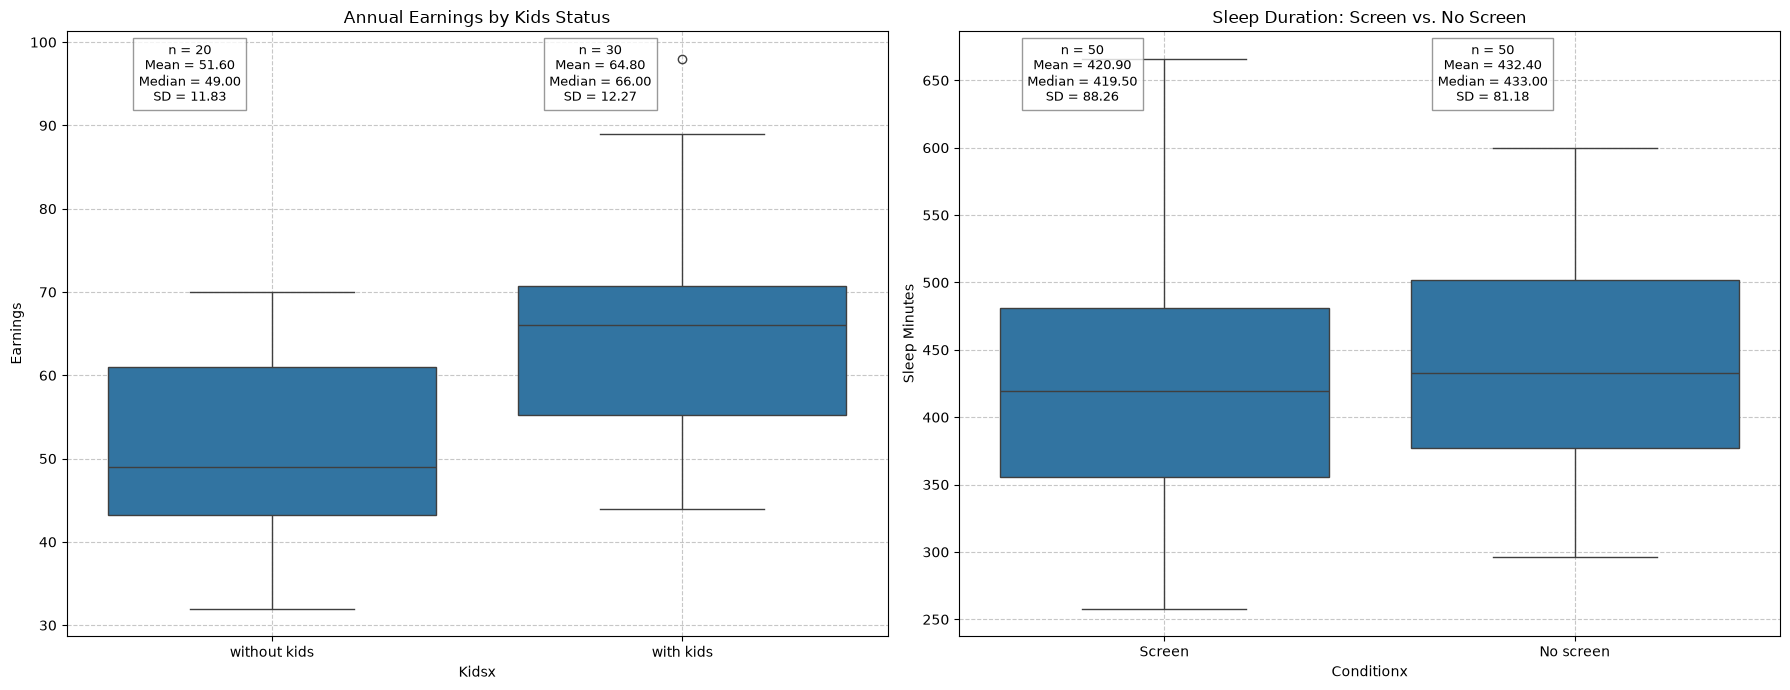

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# boxplot kids
df["kidsx"] = df["kids"].map({0:"without kids", 1:"with kids"})
plot_boxplot(
    data=df, 
    x_categorical="kidsx", 
    y_numerical="earnings",
    title="Annual Earnings by Kids Status",
    ax=axes[0], 
    display_stats=True,
    order=["without kids", "with kids"]
)

# sleep data
# reshape into long format
sleep_df = df.melt(value_vars=["sleep_screen", "sleep_noscreen"], var_name="condition", value_name="sleep_minutes")

sleep_df["conditionx"] = sleep_df["condition"].map({
    "sleep_screen": "Screen",
    "sleep_noscreen": "No screen"
})

plot_boxplot(
    data=sleep_df, 
    x_categorical="conditionx", 
    y_numerical="sleep_minutes",
    title="Sleep Duration: Screen vs. No Screen",
    ax=axes[1], 
    display_stats=True,
    order=["Screen", "No screen"]
)

plt.tight_layout()

### Reflection: boxplots

**Earnings:** The median earnings are higher for people with kids (about $66,000) than for people without kids (about $49,000). The distributions overlap, and the group with kids has a high potential outlier. The boxes show the middle 50% of values and the whiskers show the range of non-outlier values.

**Sleep:** The median is slightly higher in the no-screen condition (about 433 minutes) than in the screen condition (about 419.5 minutes). The distributions overlap considerably. Because observations are paired, separate boxplots do not show each person's change; the paired t-test analyzes the within-person differences.

## 5. Overall summary

Both tests were statistically significant at \(\alpha=0.05\).

- **Earnings:** The without-kids group had mean earnings $13,200 lower than the with-kids group, Welch's \(t=-3.808\), \(p=0.000451\), \(r=0.507\), 95% CI for the mean difference approximately \([-20.20, -6.20]\) k dollars.
- **Sleep:** The mean paired difference (screen minus no screen) was −11.5 minutes, \(t=-3.389\), \(p=0.001391\), \(r=0.436\), 95% CI approximately \([-18.32,-4.68]\) minutes.

The independent test compares separate groups; the paired test compares repeated measurements from the same people. Boxplots describe medians and distributions, while t-tests evaluate mean differences. Statistical significance does not establish causation.